# E. Marketing Funnel + Integration

Things done in this category:
1. Loading `marketing_qualified_leads_dataset.csv` and `closed_deals_dataset.csv`
2. Building `funnel_summary.csv` : a standalone lead conversion analysis
3. Investigating how much the funnel data actually overlaps with the main seller/order dataset
4. Detailed analysis of funnel growth and closing the seller quality issue
5. Building `analysis_master.csv`

In [1]:
import pandas as pd
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
mql = pd.read_csv('marketing_qualified_leads_dataset.csv')
closed = pd.read_csv('closed_deals_dataset.csv')

print("mql shape:", mql.shape)
print("closed_deals shape:", closed.shape)

mql shape: (8000, 4)
closed_deals shape: (842, 14)


In [3]:
mql.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [4]:
closed.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


## 2. Initial data quality checks

In [5]:
print("Nulls in mql:")
print(mql.isnull().sum())

Nulls in mql:
mql_id                 0
first_contact_date     0
landing_page_id        0
origin                60
dtype: int64


In [6]:
print("Origin value counts (including missing):")
print(mql['origin'].value_counts(dropna=False))

Origin value counts (including missing):
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
NaN                    60
Name: count, dtype: int64


**Finding:** `origin` already has a literal `unknown` category (1,099 rows) as well as 60 truly missing
(`NaN`) rows. These are kept as two separate categories (`unknown` vs. a new `not_specified` for
the NaN rows) rather than merged, since `unknown` likely means something specific in Olist's own
tracking (e.g. tracking failed for that lead) versus a field that was simply never recorded.

In [8]:
print("Nulls in closed_deals: ")
print(closed.isnull().sum())

Nulls in closed_deals: 
mql_id                             0
seller_id                          0
sdr_id                             0
sr_id                              0
won_date                           0
business_segment                   1
lead_type                          6
lead_behaviour_profile           177
has_company                      779
has_gtin                         778
average_stock                    776
business_type                     10
declared_product_catalog_size    773
declared_monthly_revenue           0
dtype: int64


**Finding:** heavy nulls in seller declared fields (`has_company`, `has_gtin`, `average_stock`, `declared_product_catalog_size` all more than 90% missing). These are almost certainly optional fields in the
sales conversation/survey that most sellers simply didn't answer, not a data extraction problem. Not worth imputing, so leaving as null, and don't lean on these columns for any headline finding given how sparse they are.

In [9]:
print("Distinct mql_id in mql:", mql['mql_id'].nunique(), "/", len(mql))
print("Distinct mql_id in closed_deals:", closed['mql_id'].nunique(), "/", len(closed))
print("All closed_deals mql_id found in mql table:", closed['mql_id'].isin(mql['mql_id']).sum(), "/", len(closed))

conversion_rate = round(100 * len(closed) / len(mql), 2)
print(f"\nOverall MQL to won deal conversion rate: {conversion_rate}%")


Distinct mql_id in mql: 8000 / 8000
Distinct mql_id in closed_deals: 842 / 842
All closed_deals mql_id found in mql table: 842 / 842

Overall MQL to won deal conversion rate: 10.53%


## 3. Build `funnel_summary.csv`

In [10]:
mql['origin'] = mql['origin'].fillna('not_specified')

merged = mql.merge(closed[['mql_id', 'seller_id', 'business_segment', 'lead_type', 'won_date']], on='mql_id', how='left')
merged['converted'] = merged['seller_id'].notna()

funnel_summary = merged.groupby('origin').agg(
    n_leads=('mql_id', 'count'),
    n_won=('converted', 'sum')
).reset_index()
funnel_summary['conversion_rate'] = (funnel_summary['n_won'] / funnel_summary['n_leads'] * 100).round(2)
funnel_summary = funnel_summary.sort_values('n_leads', ascending=False)

print(funnel_summary.to_string())

               origin  n_leads  n_won  conversion_rate
4      organic_search     2296    271            11.80
7         paid_search     1586    195            12.30
9              social     1350     75             5.56
10            unknown     1099    179            16.29
0      direct_traffic      499     56            11.22
2               email      493     15             3.04
8            referral      284     24             8.45
5               other      150      4             2.67
1             display      118      6             5.08
6   other_publicities       65      3             4.62
3       not_specified       60     14            23.33


In [11]:
funnel_summary.to_csv('funnel_summary.csv', index=False)
print("Saved funnel_summary.csv:", funnel_summary.shape)

Saved funnel_summary.csv: (11, 4)


**Finding:**  conversion rate varies a lot by origin, and not in the obvious direction.

- Leads with no recorded origin at all (`not_specified`, n=60) convert at the highest rate (23.3%) which is even above the literal `unknown` category (16.3%) and while common channels like `email` (3.0%) and `social` (5.6%)
convert far worse despite decent volume.

- `not_specified` is a small sample (60 leads), so that specific number is noisy, same small sample logic as Track C's seller level rates.

- `email` and `social`'s weak conversion, by contrast, are based on much larger samples (493 and 1,350 leads) and are worth taking more seriously as a real pattern.

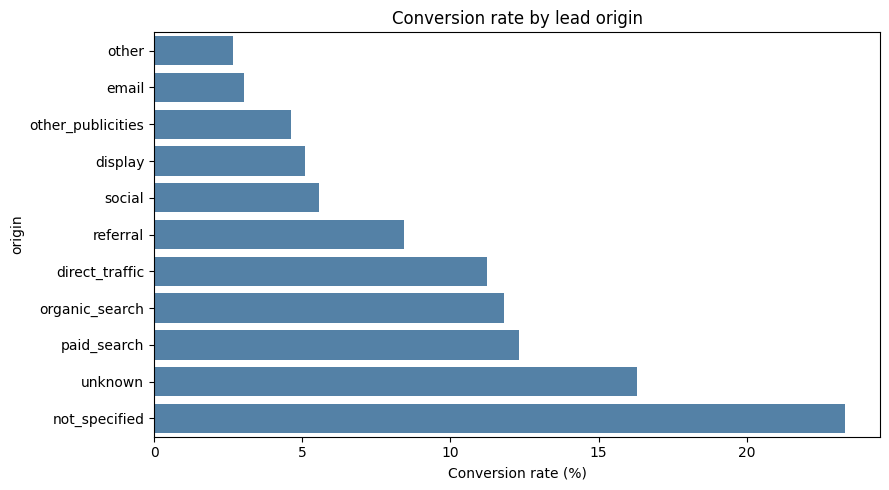

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=funnel_summary.sort_values('conversion_rate'), y='origin', x='conversion_rate', color='steelblue', ax=ax)
ax.set_title('Conversion rate by lead origin')
ax.set_xlabel('Conversion rate (%)')
plt.tight_layout()
plt.show()


### Business segment and lead type (won deals only since these fields only exist post conversion)

In [13]:
print("Top business segments among won deals:")
print(closed['business_segment'].value_counts().head(10))

Top business segments among won deals:
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
Name: count, dtype: int64


In [14]:
print("Lead type distribution:")
print(closed['lead_type'].value_counts())

Lead type distribution:
lead_type
online_medium      332
online_big         126
industry           123
offline            104
online_small        77
online_beginner     57
online_top          14
other                3
Name: count, dtype: int64


### Time to close

In [15]:
mql['first_contact_date'] = pd.to_datetime(mql['first_contact_date'])
closed['won_date'] = pd.to_datetime(closed['won_date'])
close_time = closed.merge(mql[['mql_id', 'first_contact_date']], on='mql_id', how='left')
close_time['days_to_close'] = (close_time['won_date'] - close_time['first_contact_date']).dt.total_seconds() / 86400

print(close_time['days_to_close'].describe())
print("\nRows with negative days_to_close:", (close_time['days_to_close'] < 0).sum())


count    842.000000
mean      49.100769
std       75.334901
min       -1.181308
25%        5.856803
50%       14.650729
75%       54.991004
max      427.551817
Name: days_to_close, dtype: float64

Rows with negative days_to_close: 1


**Findings:**
- One row shows a slightly negative time to close (won 1.2 days before the first contact). Which can be a data entry issue or just a mistake in logging but we can not know that for sure.

- Although since it's just a single row out of 842 total, it doesn't affect the median or mean much so not really worth chasing further.

- Time to close itself is heavily right skewed (median 15 days, mean 49 days, max 427 days) and most deals close reasonably
quickly, with a long tail of slow ones.

## 4. How much does the funnel data actually connect to the rest of the project? (important scoping finding)

This needs checking carefully in both directions and not just how many active sellers have a funnel record, but also how many funnel won deals ever show up as an active seller.

In [17]:
sellers_master = pd.read_csv('sellers_master.csv')

pct_active_with_funnel = round(100 * sellers_master['seller_id'].isin(closed['seller_id']).sum() / len(sellers_master), 1)
print(f"Active sellers (in sellers_master) WITH a funnel record: {sellers_master['seller_id'].isin(closed['seller_id']).sum()} / {len(sellers_master)} ({pct_active_with_funnel}%)")

pct_won_that_are_active = round(100 * closed['seller_id'].isin(sellers_master['seller_id']).sum() / len(closed), 1)
print(f"\nWon deals (in closed_deals) that ARE an active seller in the main dataset: {closed['seller_id'].isin(sellers_master['seller_id']).sum()} / {len(closed)} ({pct_won_that_are_active}%)")


Active sellers (in sellers_master) WITH a funnel record: 380 / 3095 (12.3%)

Won deals (in closed_deals) that ARE an active seller in the main dataset: 380 / 842 (45.1%)


**Two sided finding:**
- Only 12% of active sellers (380 of 3,095) have any tracked funnel/acquisition record at all so for the large majority of active sellers, we simply don't know how they were acquired.

- Going the other way: of the 842 won deals in `closed_deals`, only 380 (45%) ever appear as an active seller with real order history. The other 462 won deals never show up in `sellers_dataset`, meaning either they signed up but never actually listed/sold anything within this dataset's time window, or there's some other explanation not visible from this data alone (e.g. a seller_id namespace difference).

- We can't fully distinguish these explanations from the data we have so worth stating as an open limitation.

**Practical consequence:** `funnel_summary.csv` is a clean, standalone analysis of acquisition efficiency and it should not be force merged into the main satisfaction/delivery narrative (Categories A to D), since it only meaningfully connects to a small, non representative slice of sellers. Present it as its own mini story in the final report/presentation, not as an explanatory variable for the central delay vs review finding.

## 6. Some questions to think about
- Funnel data: confirmed as a standalone mini story : does the everyone agree it should not appear in the main dashboard's category/seller/region filters, only as its own separate section?

- The `email`/`social` low conversion pattern : is it worth a chart in the final report, or too tangential to the project's core satisfaction question?


# 7. Deeper Analysis: Funnel Growth & Closing the Loop on Seller Quality

The sections above establish the funnel's basic shape and the important two sided overlap limitation. This section asks two kinds of sharper questions: has the funnel itself gotten more efficient over time (the same growth lens applied to Catgories A and D), and for the 380 sellers where we can connect funnel data to real performance. Do any of the self declared signals
collected at signup actually predict how that seller performs months or years later?


## 7.1 Has the funnel gotten more efficient over time?

Track A found delivery quality did not hold steady as order volume grew. Worth checking the mirror question on the acquisition side: did conversion efficiency hold up, improve, or decline as lead volume grew?

In [18]:
mql['first_contact_date'] = pd.to_datetime(mql['first_contact_date'])
mql['contact_month'] = mql['first_contact_date'].dt.to_period('M').astype(str)

merged_time = mql.merge(closed[['mql_id', 'seller_id']], on='mql_id', how='left')
merged_time['converted'] = merged_time['seller_id'].notna()

monthly_conversion = merged_time.groupby('contact_month').agg(
    n_leads=('mql_id', 'count'), n_won=('converted', 'sum')
)
monthly_conversion['conversion_rate'] = (monthly_conversion['n_won'] / monthly_conversion['n_leads'] * 100).round(2)
monthly_conversion


,n_leads,n_won,conversion_rate
contact_month,,,
2017-06,4,0,0.00
2017-07,239,2,0.84
2017-08,386,9,2.33
2017-09,312,7,2.24
2017-10,416,14,3.37
2017-11,445,18,4.04
2017-12,200,11,5.50
2018-01,1141,152,13.32
2018-02,1028,149,14.49


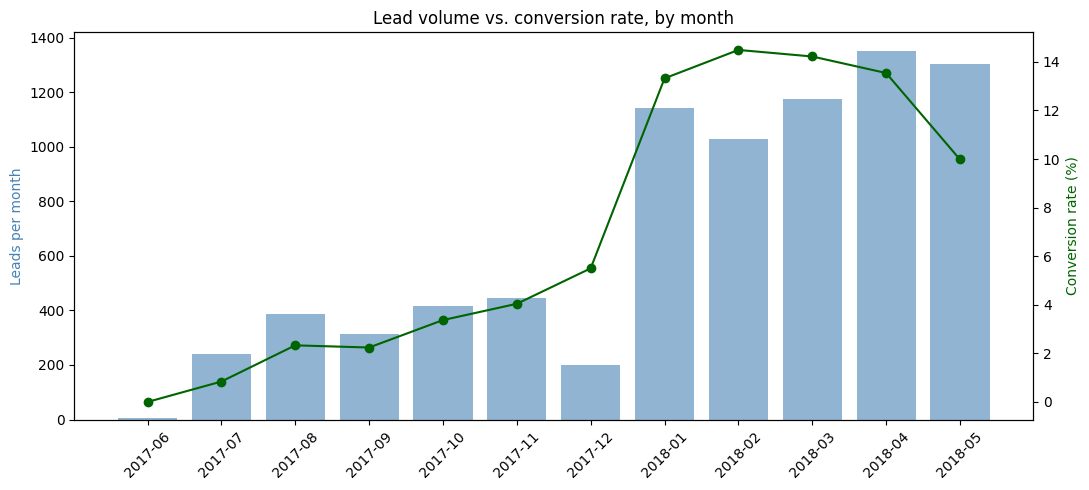

In [19]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly_conversion.index, monthly_conversion['n_leads'], color='steelblue', alpha=0.6, label='Leads')
ax1.set_ylabel('Leads per month', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_conversion.index, monthly_conversion['conversion_rate'], color='darkgreen', marker='o', label='Conversion rate (%)')
ax2.set_ylabel('Conversion rate (%)', color='darkgreen')

ax1.set_title('Lead volume vs. conversion rate, by month')
plt.tight_layout()
plt.show()


**Finding:** The conversion rate improved dramatically over
time, from under 1% in mid 2017 to 13 to 14% by early 2018, even as lead volume also grew substantially (a few hundred/month to 1,000+/month).

- Unlike delivery operations, where quality dipped as volume grew (Track A), the acquisition funnel got more efficient as it scaled. This is a genuinely useful, positive counterpoint for the final presentation's growth narrative.

**Data coverage note:** the MQL dataset only runs through May 2018, which is notably shorter than the main order data (which extends to October 2018).

## 7.2 Does a seller's declared profile at signup predict their real performance?

For the 380 sellers where funnel data connects to real order history, several fields were
collected at signup, before the seller ever shipped an order. Worth testing directly whether any
of them actually predicted what that seller's real performance turned out to be.

In [21]:
sellers_master_enhanced = pd.read_csv('sellers_master_enhanced.csv')
overlap = closed.merge(sellers_master_enhanced, on='seller_id', how='inner')
print(f"Sellers with both funnel and real performance data: {len(overlap)}")

print("\nReal performance by declared lead_type:")
print(
    overlap.groupby('lead_type')
    .agg(n=('seller_id', 'count'), avg_pct_late=('pct_late', 'mean'), avg_transport_days=('avg_transport_days', 'mean'))
    .sort_values('avg_pct_late')
)


Sellers with both funnel and real performance data: 380

Real performance by declared lead_type:
                   n  avg_pct_late  avg_transport_days
lead_type                                             
online_top         6      0.016270            4.711343
industry          41      0.028436            6.564617
online_small      28      0.035427            6.989864
online_beginner   21      0.044289            7.829465
online_big        79      0.052385            6.719363
online_medium    172      0.081253            6.048815
offline           30      0.089921            5.670909


**Finding:** a real, meaningful spread. `industry` (2.8% late) and `online_top` (1.6%, though only 6 sellers) perform notably better than `offline` (9.0%) and `online_medium` (8.1%).

- This suggests more established/larger businesses at signup do tend to become more reliable sellers which is a genuine closing the loop finding, though several of these groups are small enough (`online_top` n=6,
`industry` n=41) that this should be presented as a real but not fully robust pattern.

In [22]:
print("business_type (reseller vs. manufacturer) vs. real performance:")
print(
    overlap.groupby('business_type')
    .agg(n=('seller_id', 'count'), avg_pct_late=('pct_late', 'mean'), avg_order_value=('avg_order_value', 'mean'))
)


business_type (reseller vs. manufacturer) vs. real performance:
                 n  avg_pct_late  avg_order_value
business_type                                    
manufacturer    90      0.083720       163.487526
reseller       287      0.058705       187.088734


**Finding:** manufacturers have a higher late rate (8.4%) than resellers (5.9%), and lower average order value (163 Real vs. ₤ Real). Possible explanation not testable from this data alone (manufacturers may ship larger/custom/made to order items) so worth noting as a real pattern, not a fully explained one.

In [23]:
print("declared_product_catalog_size vs. real n_orders:")
print(overlap[['declared_product_catalog_size', 'n_orders']].corr())
print("\nNon null declared_product_catalog_size in the overlap:", overlap['declared_product_catalog_size'].notna().sum(), "/", len(overlap))


declared_product_catalog_size vs. real n_orders:
                               declared_product_catalog_size  n_orders
declared_product_catalog_size                            NaN       NaN
n_orders                                                 NaN       1.0

Non-null declared_product_catalog_size in the overlap: 0 / 380


**Finding:** The correlation returns `NaN` because `declared_product_catalog_size` is almost entirely missing even within this already small 380 seller overlap. Confirms the original data quality note (Section 2) rather than adding anything new; not worth pursuing
further with this field.

## 7.3 Does the mystery `lead_behaviour_profile` tag predict anything real?

This field's exact meaning was never established (Section 2's original note flagged it as an uninterpreted internal sales tag). Worth checking anyway whether it correlates with something measurable, even without knowing what it represents.

In [24]:
print("Real performance by lead_behaviour_profile:")
print(
    overlap.groupby('lead_behaviour_profile')
    .agg(n=('seller_id', 'count'), avg_pct_late=('pct_late', 'mean'))
    .sort_values('n', ascending=False)
    .head(6)
)


Real performance by lead_behaviour_profile:
                          n  avg_pct_late
lead_behaviour_profile                   
cat                     184      0.062272
eagle                    50      0.048210
wolf                     43      0.128078
shark                    10      0.119299
cat, wolf                 1      0.000000
eagle, cat                1      0.000000


**Finding:** whatever this tag represents internally, it correlates with real outcomes. `wolf` (12.8% late) and `shark` (11.9%, small n=10) sellers perform notably worse than `cat` (6.2%) and `eagle` (4.8%).

- Worth flagging to the team as a candidate for follow up if anyone has access to Olist's original sales documentation the pattern is real even though we can't currently explain the mechanism behind it.

## 7.4 Sales rep concentration and deal speed vs. eventual quality

Two quick checks: is deal closing concentrated among a few reps (mirroring Track C's seller concentration finding), and does closing a deal faster or slower relate to how that seller eventually performs?

In [25]:
print("Distinct sales reps:", closed['sr_id'].nunique(), "| Total deals:", len(closed))
print("\nTop 5 reps by deals closed:")
print(closed['sr_id'].value_counts().head(5))


Distinct sales reps: 22 | Total deals: 842

Top 5 reps by deals closed:
sr_id
4ef15afb4b2723d8f3d81e51ec7afefe    133
d3d1e91a157ea7f90548eef82f1955e3     82
6565aa9ce3178a5caf6171827af3a9ba     74
85fc447d336637ba1df43e793199fbc8     64
495d4e95a8cf8bbf8b432b612a2aa328     63
Name: count, dtype: int64


**Finding:** real concentration as 22 reps handle all 842 deals, and the top rep alone closed 133 (16%). Not dug into further here (would need rep-level performance context Olist's internal data would have, not this dataset), but noted as a pattern worth being aware of if any rep specific analysis is ever requested.

In [26]:
closed['won_date'] = pd.to_datetime(closed['won_date'])
closed_timing = closed.merge(mql[['mql_id', 'first_contact_date']], on='mql_id', how='left')
closed_timing['days_to_close'] = (closed_timing['won_date'] - closed_timing['first_contact_date']).dt.total_seconds() / 86400

overlap_timing = closed_timing.merge(sellers_master_enhanced, on='seller_id', how='inner')
print("Correlation, days_to_close vs. real pct_late:", round(overlap_timing['days_to_close'].corr(overlap_timing['pct_late']), 3))


Correlation, days_to_close vs. real pct_late: 0.065


**Finding:** essentially no relationship (0.065). So how long a deal took to close doesn't predict that seller's eventual delivery performance. Checked and ruled out.

## 7.5 Business segment vs. real performance real, but small sample caveated

Category 4's original section showed segment volume among won deals. This tests whether segment also relates to real performance, for the subset with both funnel and order data.

In [27]:
top_segments = closed['business_segment'].value_counts().head(10).index
segment_perf = (
    overlap[overlap['business_segment'].isin(top_segments)]
    .groupby('business_segment')
    .agg(n=('seller_id', 'count'), avg_pct_late=('pct_late', 'mean'))
    .sort_values('avg_pct_late', ascending=False)
)
segment_perf


,n,avg_pct_late
business_segment,,
food_drink,9,0.138889
home_decor,44,0.133602
construction_tools_house_garden,32,0.101981
car_accessories,30,0.068212
household_utilities,44,0.051775
audio_video_electronics,31,0.051335
health_beauty,45,0.049603
pet,17,0.048765
food_supplement,8,0.045139


**Finding:** a real spread (1.2% for `computers` up to  14% for `food_drink`/`home_decor`), but several segments here have very few sellers within the 380 seller overlap (`food_drink` n=9, `computers` n=12). So worth presenting with an explicit small sample caveat.

## 7.6 Some more questions to think about

- The funnel's improving efficiency (7.1) vs. Category A's operational quality dips is worth using as a deliberate contrast in the final presentation: acquisition got better as the marketplace scaled, operations didn't uniformly keep up.

- `lead_type` and `business_type` both show real, explainable signal (7.2) is worth considering whether Olist could use signup time information to flag higher risk new sellers early, before they've shipped a single order.

- `lead_behaviour_profile`'s mechanism is still unknown despite a real correlation with outcomes (7.3).

- All small sample findings in this section (lead_type's `online_top`, several business segments) should carry their sample sizes visibly if they make it into the final report or dashboard which is consistent with how Category C's `low_confidence` flag and Category D's small sample cautions were handled throughout the project.

# 8. Building `analysis_master.csv`

**Column naming convention used throughout:** every column pulled in from `sellers_master_enhanced.csv`
is prefixed `seller_` (e.g. `seller_avg_delivery_days`), to keep a clear distinction between an order's own actual values (e.g. `delivery_days`) and a seller's typical/average values (e.g. `seller_avg_delivery_days`) sitting side by side in the same wide table which is easy to mix up otherwise when building charts.


## 8.1 Load every track's output file

In [28]:
# orders_master.csv (Track A) is the spine for the whole join
orders_master = pd.read_csv('orders_master.csv')
print("orders_master:", orders_master.shape)

orders_master: (99441, 21)


In [29]:
order_products_summary = pd.read_csv('order_products_summary.csv')
reviews_clean = pd.read_csv('reviews_clean.csv')
customers_master = pd.read_csv('customers_master.csv')
order_logistics_master = pd.read_csv('order_logistics_master.csv')
# sellers_master_enhanced already loaded in Section 7

## 8.2 Check for column name collisions before merging anything

Several files share column names for real reasons (e.g. Category B merged in `is_canceled` and `purchase_month` from Category A during its own deeper pass; Category C's `order_logistics_master.csv` carries copies of several `orders_master.csv` timestamp columns since it was built by merging
against it). Left unhandled, a pandas merge would silently suffix these `_x`/`_y` rather than error so checking explicitly first, rather than discovering it after the fact.

In [30]:
files_to_check = {
    'orders_master': orders_master,
    'order_products_summary': order_products_summary,
    'reviews_clean': reviews_clean,
    'customers_master': customers_master,
    'order_logistics_master': order_logistics_master,
    'sellers_master_enhanced': sellers_master_enhanced,
}

names = list(files_to_check.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        overlap = set(files_to_check[names[i]].columns) & set(files_to_check[names[j]].columns)
        if overlap:
            print(f"{names[i]} & {names[j]}: {overlap}")


orders_master & order_products_summary: {'purchase_month', 'is_canceled', 'order_id'}
orders_master & reviews_clean: {'order_id'}
orders_master & customers_master: {'customer_id'}
orders_master & order_logistics_master: {'customer_id', 'order_status', 'is_delivered', 'carrier_ts', 'delivered_ts', 'purchase_ts', 'estimated_delivery_ts', 'delivery_delay_days', 'approved_ts', 'is_late', 'purchase_month', 'order_id'}
order_products_summary & reviews_clean: {'order_id'}
order_products_summary & order_logistics_master: {'purchase_month', 'n_items', 'order_id'}
reviews_clean & order_logistics_master: {'order_id'}
customers_master & order_logistics_master: {'customer_id', 'customer_state'}
customers_master & sellers_master_enhanced: {'lng', 'lat'}
order_logistics_master & sellers_master_enhanced: {'seller_id', 'freight_ratio', 'seller_state'}


**Confirmed collisions to handle** (beyond the join keys `order_id`/`customer_id`/`seller_id`, which are fine): `purchase_month`/`is_canceled` (A & B), a block of timestamp/status columns plus `delivery_delay_days`/`is_delivered`/`is_late`/`purchase_month` (A & C's order level file),
`n_items` (B & C), `customer_state` (D's customers & C's order level file), and `lat`/`lng` plus `freight_ratio` (D's customers & C's seller level file).

Each resolved explicitly below either dropped (exact duplicate, already coming in from elsewhere) or renamed (genuinely different thing that happens to share a name, e.g. an order's own freight ratio vs. a seller's average freight ratio).

## 8.3 Build the join, step by step

In [31]:
analysis_master = orders_master.copy()
print(f"Step 1 (spine): {analysis_master.shape}")

Step 1 (spine): (99441, 21)


In [32]:
# + order_products_summary : drop is_canceled/purchase_month, exact duplicates of columns
# already in orders_master (Category B merged them in during its own deeper pass).
ops_to_add = order_products_summary.drop(columns=['is_canceled', 'purchase_month'])
analysis_master = analysis_master.merge(ops_to_add, on='order_id', how='left')
print(f"Step 2 (+ order_products_summary): {analysis_master.shape}")

Step 2 (+ order_products_summary): (99441, 26)


In [33]:
# + reviews_clean : no collisions.
analysis_master = analysis_master.merge(reviews_clean, on='order_id', how='left')
print(f"Step 3 (+ reviews_clean): {analysis_master.shape}")

Step 3 (+ reviews_clean): (99441, 29)


In [34]:
# + customers_master : rename lat/lng now, since sellers_master_enhanced also has lat/lng
# and would otherwise collide later.
customers_to_add = customers_master.rename(columns={'lat': 'customer_lat', 'lng': 'customer_lng'})
analysis_master = analysis_master.merge(customers_to_add, on='customer_id', how='left')
print(f"Step 4 (+ customers_master): {analysis_master.shape}")

Step 4 (+ customers_master): (99441, 35)


In [35]:
# + order_logistics_master : dedup to one row per order first (a small number of orders
# span multiple sellers; keep the highest value item's row, same convention as Category B's
# primary category rule). Then select only genuinely new columns excluding everything
# already present from orders_master, order_products_summary, or customers_master.
olm_dedup = (
    order_logistics_master.sort_values('order_item_value', ascending=False)
    .drop_duplicates('order_id')
)

olm_cols_to_add = olm_dedup[[
    'order_id', 'seller_id', 'seller_state', 'processing_days', 'transport_days',
    'delivery_days_calc', 'days_early', 'days_late', 'delay_band',
    'order_item_value', 'freight_value', 'freight_ratio',
    'purchase_weekday', 'same_state', 'distance_km'
]]
analysis_master = analysis_master.merge(olm_cols_to_add, on='order_id', how='left')
print(f"Step 5 (+ order_logistics_master): {analysis_master.shape}")


Step 5 (+ order_logistics_master): (99441, 49)


In [36]:
# + sellers_master_enhanced : prefix every non key column with 'seller_' (see naming
# convention note above). This also resolves the freight_ratio and lat/lng collisions.
seller_rename = {
    c: f'seller_{c}' for c in sellers_master_enhanced.columns
    if c not in ['seller_id', 'seller_city', 'seller_state']  # seller_state already added in step 5
}
sellers_to_add = sellers_master_enhanced.rename(columns=seller_rename).drop(columns=['seller_state'])
analysis_master = analysis_master.merge(sellers_to_add, on='seller_id', how='left')
print(f"Step 6 (+ sellers_master_enhanced): {analysis_master.shape}")


Step 6 (+ sellers_master_enhanced): (99441, 69)


## 8.4 Verify the join before trusting it

Three checks: no silent `_x`/`_y` collision suffixes, row count didn't change (a merge bug would typically show up as unexpected row duplication), and the central delay vs review finding reproduces exactly from the joined table alone. So if the join were subtly wrong, this number
would drift from the value already established independently in Category D.

In [37]:
suffix_cols = [c for c in analysis_master.columns if c.endswith('_x') or c.endswith('_y')]
print("Columns with _x/_y suffix (should be empty):", suffix_cols)

print(f"\nFinal shape: {analysis_master.shape}")
print(f"Distinct order_id: {analysis_master['order_id'].nunique()} (should equal row count above)")


Columns with _x/_y suffix (should be empty): []

Final shape: (99441, 69)
Distinct order_id: 99441 (should equal row count above)


In [38]:
delivered_check = analysis_master[analysis_master['is_delivered']].copy()
delivered_check['delay_bucket'] = pd.cut(
    delivered_check['delivery_delay_days'],
    bins=[-200, -7, 0, 3, 7, 999],
    labels=['5+ days early', 'on time/early', '1-3 days late', '4-7 days late', '8+ days late']
)
print("Re derived from analysis_master directly, should match Category D's original finding exactly:")
print(delivered_check.groupby('delay_bucket', observed=True)['review_score'].mean().round(2))


Re derived from analysis_master directly, should match Category D's original finding exactly:
delay_bucket
5+ days early    4.32
on time/early    4.20
1-3 days late    3.77
4-7 days late    2.32
8+ days late     1.73
Name: review_score, dtype: float64


**Verified:** reproduces Category D's original numbers exactly (4.32 / 4.20 / 3.77 / 2.32 / 1.73),
row count is unchanged at 99,441 (matching `orders_master.csv`), and no collision suffixes exist
anywhere in the 69 final columns. Null counts also check out against known gaps: 775 nulls in
`seller_id`/`primary_category` (matches Category B's 775 orders with no items finding exactly), 768 nulls in `review_score` (all orders with no review, a superset of Category D's 646 delivered orders with no review  figure).

## 8.5 Save `analysis_master.csv`

In [39]:
analysis_master.to_csv('analysis_master.csv', index=False)
print("Saved analysis_master.csv:", analysis_master.shape)
analysis_master.head()

Saved analysis_master.csv: (99441, 69)


,order_id,customer_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_delivery_ts,approval_hours,carrier_handoff_days,delivery_days,delivery_delay_days,is_delivered,is_canceled,is_late,total_payment_value,payment_type_primary,max_installments,n_payment_rows,purchase_month,is_split_payment,primary_category,n_items,n_distinct_categories,total_price,total_freight,review_score,has_comment,days_to_review_response,customer_unique_id,customer_city,customer_state,customer_lat,customer_lng,customer_order_count,seller_id,seller_state,processing_days,transport_days,delivery_days_calc,days_early,days_late,delay_band,order_item_value,freight_value,freight_ratio,purchase_weekday,same_state,distance_km,seller_city,seller_lat,seller_lng,seller_low_confidence,seller_size_bucket,seller_n_orders,seller_avg_processing_days,seller_median_processing_days,seller_avg_transport_days,seller_median_transport_days,seller_avg_delivery_days,seller_median_delivery_days,seller_avg_delivery_delay,seller_median_delivery_delay,seller_pct_late,seller_pct_early,seller_pct_on_time,seller_avg_freight,seller_avg_order_value,seller_freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2.366493,8.436574,-7.107488,True,False,False,38.71,voucher,1.0,3.0,2017-10,True,housewares,1.0,1.0,29.99,8.72,4.0,True,1.155417,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,-23.576170,-46.587276,2,3504c0cb71d7fa48d967e0e4c94d59d9,SP,2.373924,6.062650,8.436574,7.107488,0.0,3+ days early,29.99,8.72,0.290764,Monday,True,18.681711,maua,-23.681180,-46.444127,False,21-100,53.0,1.836973,1.695336,5.490815,5.151123,7.327788,6.356713,-10.038098,-9.484942,0.000000,1.000000,0.0,12.969245,44.338491,0.292505
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,0.462882,13.782037,-5.355729,True,False,False,141.46,boleto,1.0,1.0,2018-07,False,perfumery,1.0,1.0,118.70,22.76,4.0,True,0.776273,af07308b275d755c9edb36a90c618231,barreiras,BA,-12.126651,-45.008162,1,289cdb325fb7e7f891c38608bf9e0962,SP,1.742627,12.039410,13.782037,5.355729,0.0,3+ days early,118.70,22.76,0.191744,Tuesday,False,861.035367,belo horizonte,-19.807013,-43.980966,False,100+,110.0,1.617724,1.149514,5.105272,4.179016,6.728997,5.663507,-9.661952,-9.153194,0.018182,0.972727,0.0,19.039455,123.135909,0.154621
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,0.204595,9.394213,-17.245498,True,False,False,179.12,credit_card,3.0,1.0,2018-08,False,auto,1.0,1.0,159.90,19.22,5.0,False,4.797199,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,-16.744472,-48.514624,1,4869f7a5dfa277a7dca6462dcf3b52b2,SP,0.216100,9.178113,9.394213,17.245498,0.0,3+ days early,159.90,19.22,0.120200,Wednesday,False,514.547140,guariba,-21.364020,-48.228831,False,100+,1132.0,2.753591,2.375266,12.308213,9.006429,15.062424,12.113322,-10.390535,-12.008027,0.114841,0.878092,0.0,17.816316,202.714337,0.087889
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,3.745833,13.208750,-12.980069,True,False,False,72.20,credit_card,1.0,1.0,2017-11,False,pet_shop,1.0,1.0,45.00,27.20,5.0,True,2.806921,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,-5.774611,-35.273916,1,66922902710d126a0e7d26b0e3805106,MG,3.758252,9.450498,13.208750,12.980069,0.0,3+ days early,45.00,27.20,0.604444,Saturday,False,1821.802656,belo horizonte,-19.836541,-43.921855,False,100+,151.0,3.083276,2.861435,8.224164,6.286007,11.319269,9.316759,-9.621405,-10.226383,0.072848,0.920530,0.0,21.316358,95.114570,0.224112
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4f

## 8.6 Column reference

69 columns total. Grouped by origin for quick reference : full descriptions in `data_dictionary.md`.

- **From `orders_master.csv` (21):** order/payment/timing fields, `purchase_month`, `is_split_payment`.
- **From `order_products_summary.csv` (5 new):** `primary_category`, `n_items`, `n_distinct_categories`, `total_price`, `total_freight`.
- **From `reviews_clean.csv` (3):** `review_score`, `has_comment`, `days_to_review_response`.
- **From `customers_master.csv` (6 new):** `customer_unique_id`, `customer_city`, `customer_state`, `customer_lat`, `customer_lng`, `customer_order_count`.
- **From `order_logistics_master.csv` (14 new):** `seller_id`, `seller_state`, `processing_days`, `transport_days`, `delivery_days_calc`, `days_early`, `days_late`, `delay_band`, `order_item_value`, `freight_value`, `freight_ratio`, `purchase_weekday`, `same_state`, `distance_km`.
- **From `sellers_master_enhanced.csv` (20 new, all `seller_`-prefixed except `seller_city`):** every seller-level aggregate — processing/transport/delivery averages and medians, `seller_pct_late`/`seller_pct_early`/`seller_pct_on_time`, `seller_low_confidence`, `seller_size_bucket`, `seller_freight_ratio`, `seller_lat`/`seller_lng`.

**Usage note:** filter on `seller_low_confidence == False` for any chart ranking sellers, same caution used throughout Category C and D.
